In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
df = pd.read_csv("/content/drive/MyDrive/Forage'/JPMorganChase&Co/Nat_Gas.csv")

In [5]:
df.head()

,Dates,Prices
0,10/31/20,10.1
1,11/30/20,10.3
2,12/31/20,11.0
3,1/31/21,10.9
4,2/28/21,10.9


In [6]:
df["Dates"] = pd.to_datetime(df["Dates"])
df = df.sort_values("Dates")

/tmp/ipykernel_1346/4150226281.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Dates"] = pd.to_datetime(df["Dates"])


In [7]:
df.head()

,Dates,Prices
0,2020-10-31,10.1
1,2020-11-30,10.3
2,2020-12-31,11.0
3,2021-01-31,10.9
4,2021-02-28,10.9


In [8]:
# Create time index
df["Time"] = np.arange(len(df))

In [9]:
df.head()

,Dates,Prices,Time
0,2020-10-31,10.1,0
1,2020-11-30,10.3,1
2,2020-12-31,11.0,2
3,2021-01-31,10.9,3
4,2021-02-28,10.9,4


In [10]:
# -------------------------------
# Trend Estimation
# -------------------------------

# Fit a linear trend
coeff = np.polyfit(df["Time"], df["Prices"], 1)

trend = np.poly1d(coeff)

df["Trend"] = trend(df["Time"])

In [11]:
df.head()

,Dates,Prices,Time,Trend
0,2020-10-31,10.1,0,10.290272
1,2020-11-30,10.3,1,10.329285
2,2020-12-31,11.0,2,10.368299
3,2021-01-31,10.9,3,10.407312
4,2021-02-28,10.9,4,10.446325


In [12]:
df["Trend"] = trend(df["Time"])

In [13]:
df.head()

,Dates,Prices,Time,Trend
0,2020-10-31,10.1,0,10.290272
1,2020-11-30,10.3,1,10.329285
2,2020-12-31,11.0,2,10.368299
3,2021-01-31,10.9,3,10.407312
4,2021-02-28,10.9,4,10.446325


In [14]:
# -------------------------------
# Seasonal Component
# -------------------------------

df["Month"] = df["Dates"].dt.month

df["Seasonality"] = df["Prices"] - df["Trend"]

monthly_seasonality = (
    df.groupby("Month")["Seasonality"]
    .mean()
)


In [15]:
df.head()

,Dates,Prices,Time,Trend,Month,Seasonality
0,2020-10-31,10.1,0,10.290272,10,-0.190272
1,2020-11-30,10.3,1,10.329285,11,-0.029285
2,2020-12-31,11.0,2,10.368299,12,0.631701
3,2021-01-31,10.9,3,10.407312,1,0.492688
4,2021-02-28,10.9,4,10.446325,2,0.453675


In [16]:
# -------------------------------
# Forecast Next 12 Months
# -------------------------------

future_dates = pd.date_range(
    start=df["Dates"].max() + pd.offsets.MonthEnd(1),
    periods=12,
    freq="M"
)

future_time = np.arange(
    len(df),
    len(df)+12
)

future_trend = trend(future_time)

future_prices = []

for i, date in enumerate(future_dates):
    seasonal = monthly_seasonality[date.month]
    future_prices.append(future_trend[i] + seasonal)

forecast = pd.DataFrame({
    "Dates": future_dates,
    "Prices": future_prices
})


/tmp/ipykernel_1346/3703900258.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  future_dates = pd.date_range(


In [17]:
# -------------------------------
# Combine Historical + Forecast
# -------------------------------

all_data = pd.concat([
    df[["Dates","Prices"]],
    forecast
]).reset_index(drop=True)

# -------------------------------
# Interpolation Function
# -------------------------------

x = all_data["Dates"].map(pd.Timestamp.toordinal)
y = all_data["Prices"]

price_function = interp1d(
    x,
    y,
    fill_value="extrapolate"
)

def estimate_price(date):

    """
    Estimate natural gas price for any date.

    Example:
        estimate_price("2023-08-15")
    """

    date = pd.Timestamp(date)

    return float(price_function(date.toordinal()))


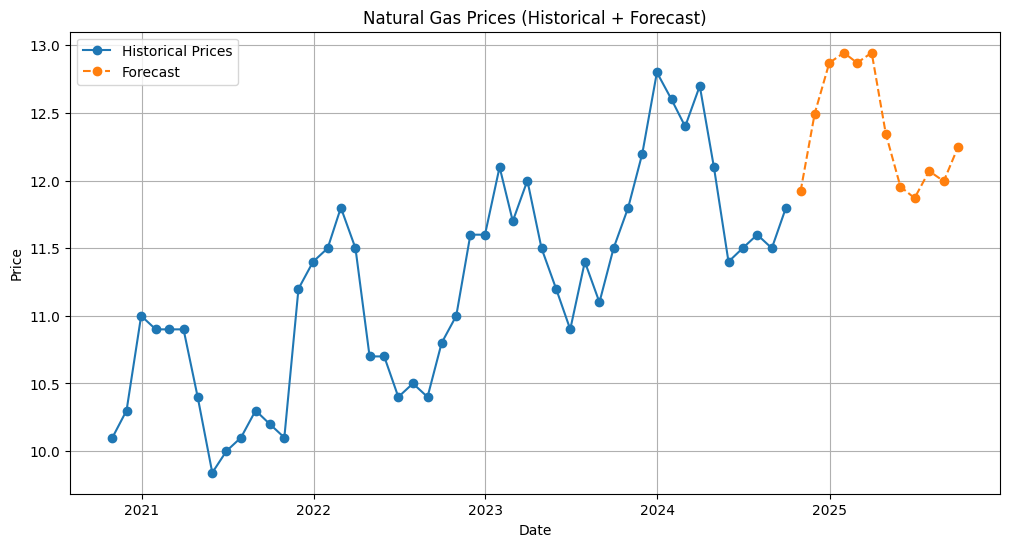

In [18]:
# -------------------------------
# Visualization
# -------------------------------

plt.figure(figsize=(12,6))

plt.plot(
    df["Dates"],
    df["Prices"],
    label="Historical Prices",
    marker="o"
)

plt.plot(
    forecast["Dates"],
    forecast["Prices"],
    label="Forecast",
    linestyle="--",
    marker="o"
)

plt.title("Natural Gas Prices (Historical + Forecast)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(True)
plt.legend()

plt.show()

In [19]:
# -------------------------------
# Example
# -------------------------------

print("Estimated Price on 2023-08-15 :",
      round(estimate_price("2023-08-15"),2))

print("Estimated Price on 2025-03-20 :",
      round(estimate_price("2025-03-20"),2))

Estimated Price on 2023-08-15 : 11.25
Estimated Price on 2025-03-20 : 12.92
